# Kaggle

В этом домашнем задании вам нужно будет построить модель для данных соревнования [Titanic на Kaggle](https://www.kaggle.com/c/titanic/overview), сформировать файл с предсказаниями для тестовых данных и отправить его на проверку.

В практике из урока вашим заданием было разобрать одно из самых популярных ядер для соревнования Titanic и преобразовать его таким образом, чтобы остались только преобразование данных и графики.

Соответственно, сейчас ваше ядро должно выглядеть таким образом:

In [2]:
import pandas as pd
import re
import numpy as np

from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load in the train and test datasets
telecom = pd.read_csv('telecom_users.csv')


# Store our passenger ID for easy access
#PassengerId = test['PassengerId']

telecom.head(5)

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1869,7010-BRBUU,Male,0,Yes,Yes,72,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,1734.65,No
1,4528,9688-YGXVR,Female,0,No,No,44,Yes,No,Fiber optic,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,3973.2,No
2,6344,9286-DOJGF,Female,1,Yes,No,38,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,2869.85,Yes
3,6739,6994-KERXL,Male,0,No,No,4,Yes,No,DSL,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,238.5,No
4,432,2181-UAESM,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,119.5,No


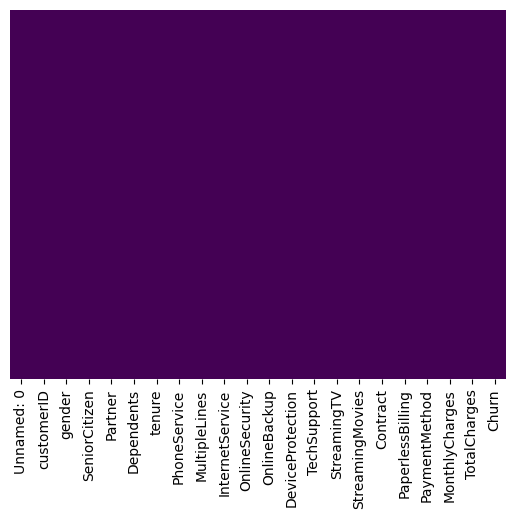

In [6]:
#анализ наполненности дата фрейма
sns.heatmap(telecom.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.show()


In [63]:
# Создаем функцию для анализа уникальных значений
def analyze_unique_values(df, max_categories=20):
    print("Анализ уникальных значений постолбцам")
    
    for column in df.columns:
        unique_count = df[column].nunique()
        unique_values = df[column].unique()
        
        print(f"\n Столбец: {column}")
        print(f"   Тип данных: {df[column].dtype}")
        print(f"   Количество уникальных значений: {unique_count}")
        #print(f"   Количество пропусков: {df[column].isnull().sum()}")
        
        if unique_count <= max_categories:
            print(f"   Уникальные значения: {list(unique_values)}")
        else:
            print(f"   Уникальные значения: {list(unique_values[:max_categories])} ... \nколичество остальных знач.: {unique_count - max_categories}")


#применяем анализ ко всему датафрейму
analyze_unique_values(telecom)

Анализ уникальных значений постолбцам

 Столбец: Unnamed: 0
   Тип данных: int64
   Количество уникальных значений: 5986
   Уникальные значения: [1869, 4528, 6344, 6739, 432, 2215, 5260, 6001, 1480, 5137, 3169, 4653, 2850, 1760, 604, 2157, 3132, 6765, 6508, 5636] ... 
количество остальных знач.: 5966

 Столбец: customerID
   Тип данных: object
   Количество уникальных значений: 5986
   Уникальные значения: ['7010-BRBUU', '9688-YGXVR', '9286-DOJGF', '6994-KERXL', '2181-UAESM', '4312-GVYNH', '2495-KZNFB', '4367-NHWMM', '8898-KASCD', '8016-NCFVO', '4578-PHJYZ', '2091-MJTFX', '2277-DJJDL', '2511-MORQY', '2731-GJRDG', '1784-EZDKJ', '2468-SJFLM', '5115-SQAAU', '8708-XPXHZ', '0601-WZHJF'] ... 
количество остальных знач.: 5966

 Столбец: gender
   Тип данных: object
   Количество уникальных значений: 2
   Уникальные значения: ['Male', 'Female']

 Столбец: SeniorCitizen
   Тип данных: int64
   Количество уникальных значений: 2
   Уникальные значения: [0, 1]

 Столбец: Partner
   Тип данных: obj

In [84]:
#разбиваем на категории столбцы, где есть нескольк опеременных
telecom['tenure'] = pd.to_numeric(telecom['tenure'], errors='coerce')
# Вычислим статистики
tenure_avg = telecom['tenure'].mean()
tenure_std = telecom['tenure'].std()
total_charges_null_count = telecom['tenure'].isnull().sum()

print(f"Среднее: {tenure_avg:.2f}")
print(f"Стандартное отклонение: {tenure_std:.2f}")
print(f"Пропуски: {total_charges_null_count}")

Среднее: 32.47
Стандартное отклонение: 24.52
Пропуски: 0


In [85]:
print("распределение по категориям:")
for i, (interval, count) in enumerate(category_counts.items()):
    percentage = (count / len(telecom)) * 100
    print(f"Категория {i+1}: {interval}")
    print(f"  Количество: {count} ({percentage:.1f}%)")


распределение по категориям:
Категория 1: (18.249, 25.1]
  Количество: 1215 (20.3%)
Категория 2: (25.1, 58.6]
  Количество: 1183 (19.8%)
Категория 3: (58.6, 79.15]
  Количество: 1194 (19.9%)
Категория 4: (79.15, 94.35]
  Количество: 1200 (20.0%)
Категория 5: (94.35, 118.75]
  Количество: 1194 (19.9%)


In [83]:
#обрабатываем колонку MonthlyCharges
#создаем столбец
telecom['CategoricalMonthlyCharges'] = pd.qcut(telecom['MonthlyCharges'], 5, duplicates='drop')
#распределение по категориям
category_counts = telecom['CategoricalMonthlyCharges'].value_counts().sort_index()

In [73]:
#обрабатываем колонку TotalCharges

#заполняем пропуски
if total_charges_null_count > 0:
    #более безопасный подход: используем медиану вместо нормального распределения
    total_charges_median = telecom['TotalCharges'].median()
    total_charges_iqr = telecom['TotalCharges'].quantile(0.75) - telecom['TotalCharges'].quantile(0.25)
    #генерируем значения в реалистичном диапазоне
    random_charges = np.random.uniform(max(0, total_charges_median - total_charges_iqr), total_charges_median + total_charges_iqr, size=total_charges_null_count
    )
    
    telecom['TotalCharges'] = telecom['TotalCharges'].fillna(pd.Series(random_charges, index=telecom.index[telecom['TotalCharges'].isnull()])
    )
#распределение по категориям
category_counts = telecom['CategoricalTotalCharges'].value_counts().sort_index()

In [96]:
#сохраняем некоторые столбцы отдельно для идентификации, остальные преобразовываем в номвый датасет
customer_ids = telecom['customerID'].copy()
customer_Unnamed = telecom['Unnamed: 0'].copy()
#сохраняем идентификаторы для возможного последующего использования
identification_data = pd.DataFrame({
    'customerID': customer_ids,
    'Unnamed: 0': customer_Unnamed
})
#создаем новый датафрейм для ML
telecom_ml = pd.DataFrame(index=telecom.index)

telecom_ml['gender'] = telecom['gender'].map( {'Female': 0, 'Male': 1} ).astype(int)
telecom_ml['SeniorCitizen'] = telecom['SeniorCitizen']
telecom_ml['Partner'] = telecom['Partner'].map( {'Yes': 1, 'No': 0} ).astype(int)
telecom_ml['Dependents'] = telecom['Dependents'].map( {'Yes': 1, 'No': 0} ).astype(int)
telecom_ml['CategoricalTenure'] = pd.cut(telecom['tenure'], 5, labels=False)
telecom_ml['PhoneService'] = telecom['PhoneService'].map( {'Yes': 0, 'No': 1} ).astype(int)
telecom_ml['MultipleLines'] = telecom['MultipleLines'].map( {'Yes': 0, 'No': 1, 'No phone service': 2} ).astype(int)
telecom_ml['InternetService'] = telecom['InternetService'].map( {'No': 0, 'Fiber optic': 1, 'DSL': 2} ).astype(int)
telecom_ml['OnlineSecurity'] = telecom['OnlineSecurity'].map( {'No internet service': 0, 'No': 1, 'Yes': 2} ).astype(int)
telecom_ml['OnlineBackup'] = telecom['OnlineBackup'].map( {'No internet service': 0, 'Yes': 1, 'No': 2} ).astype(int)
telecom_ml['DeviceProtection'] = telecom['DeviceProtection'].map( {'No internet service': 0, 'Yes': 1, 'No': 2} ).astype(int)
telecom_ml['TechSupport'] = telecom['TechSupport'].map( {'No internet service': 0, 'No': 1, 'Yes': 2} ).astype(int)
telecom_ml['StreamingTV'] = telecom['StreamingTV'].map( {'No internet service': 0, 'Yes': 1, 'No': 2} ).astype(int)
telecom_ml['StreamingMovies'] = telecom['StreamingMovies'].map( {'No internet service': 0, 'No': 1, 'Yes': 2} ).astype(int)
telecom_ml['Contract'] = telecom['Contract'].map( {'Two year': 0, 'Month-to-month': 1, 'One year': 2} ).astype(int)
telecom_ml['PaperlessBilling'] = telecom['PaperlessBilling'].map( {'Yes': 1, 'No': 0} ).astype(int)
telecom_ml['PaymentMethod'] = telecom['PaymentMethod'].map( {'Credit card (automatic)': 0, 'Bank transfer (automatic)': 1, 'Electronic check': 2, 'Mailed check': 3} ).astype(int)
telecom_ml['CategoricalMonthlyCharges'] = pd.qcut(telecom['MonthlyCharges'], 5, labels=False, duplicates='drop')
telecom_ml['CategoricalTotalCharges'] = pd.qcut(telecom['TotalCharges'], 5, labels=False, duplicates='drop')
telecom_ml['Churn'] = telecom['Churn'].map( {'Yes': 1, 'No': 0} ).astype(int)

#собираем в список новые столбцы. которые образовались в процессе анализа
columns_to_drop = [
    'customerID', 'Unnamed: 0', 'customerID_length', 'ID_region', 
    'customerID_grouped', 'ID_type', 'customerID_encoded', 'customerID_hash',
    'ID_prefix1', 'ID_prefix2', 'ID_prefix3', 'ID_prefix4', 'Churn_numeric',
    'numeric_part', 'id_group', 'gender_rare'
]
#удаляем только существующие столбцы
existing_columns_to_drop = [col for col in columns_to_drop if col in telecom.columns]



In [97]:
telecom_ml.head()

,gender,SeniorCitizen,Partner,Dependents,CategoricalTenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,CategoricalMonthlyCharges,CategoricalTotalCharges,Churn
0,1,0,1,1,4,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
1,0,0,0,0,3,0,1,1,1,1,1,1,1,1,1,1,0,3,3,0
2,0,1,1,0,2,0,0,1,1,2,2,1,2,1,1,1,1,2,3,1
3,1,0,0,0,0,0,1,2,1,2,2,1,2,2,1,1,2,1,0,0
4,1,0,0,0,0,0,1,2,2,2,1,1,2,1,1,0,2,1,0,0


<Axes: title={'center': 'Pearson Correlation of Features'}>

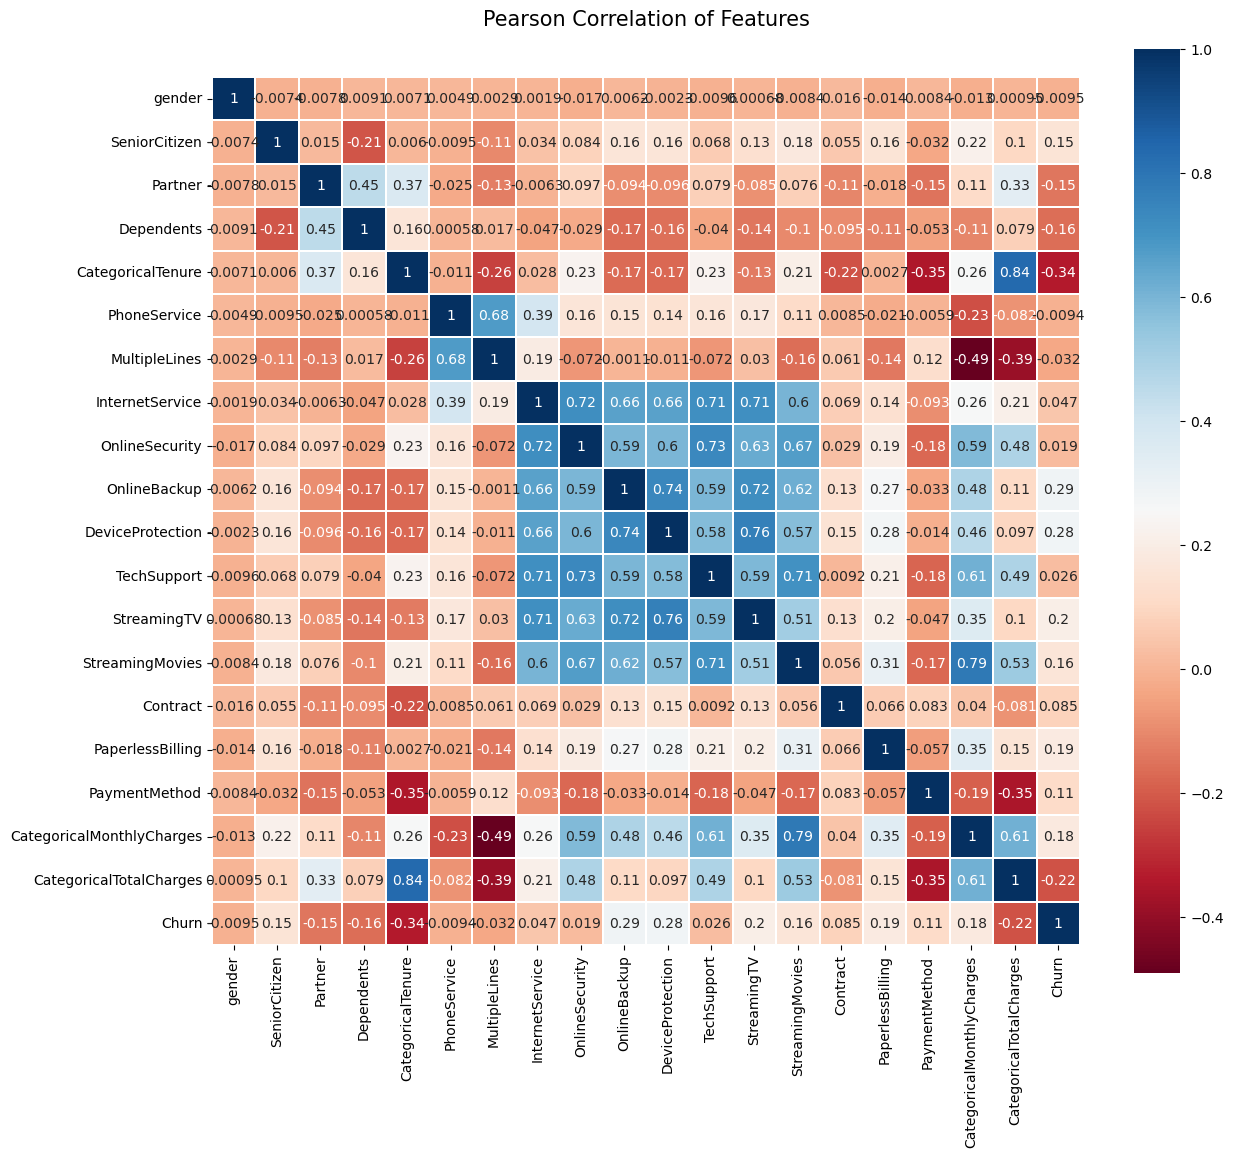

In [102]:
colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(telecom_ml.astype(float).corr(),linewidths=0.1,vmax=1.0,
            square=True, cmap=colormap, linecolor='white', annot=True)

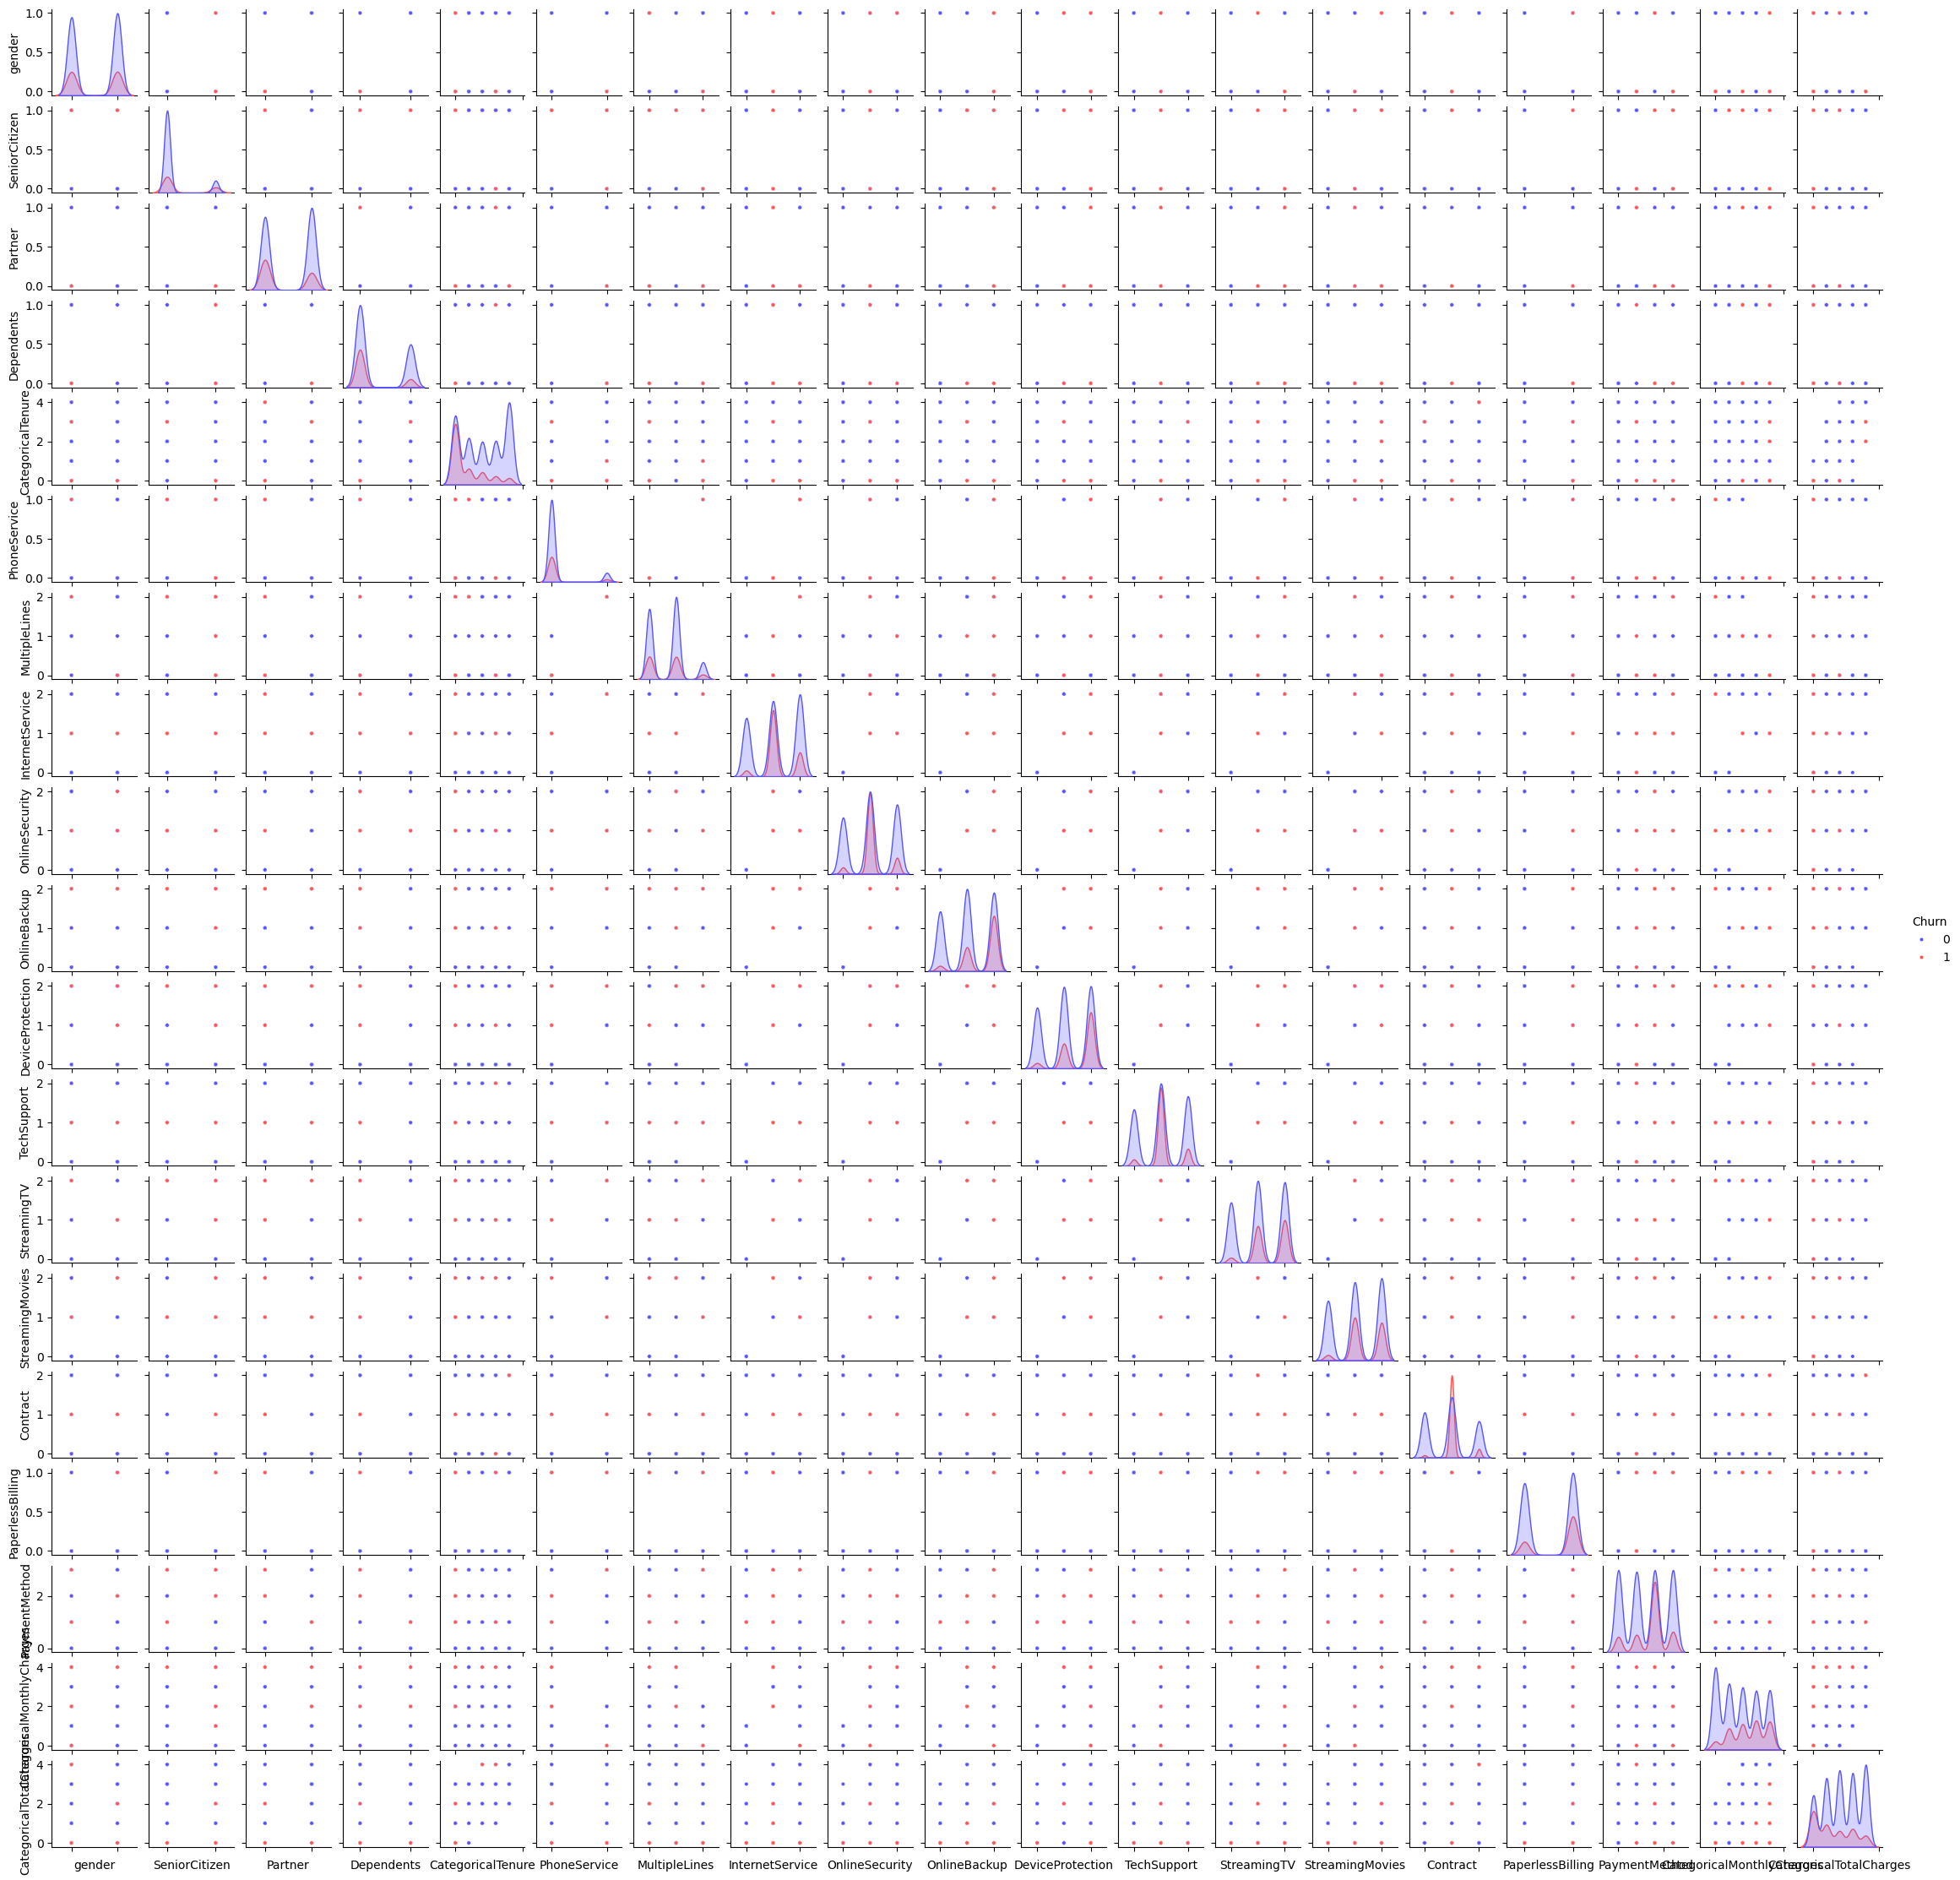

In [105]:
g = sns.pairplot(telecom_ml,
                 hue='Churn', palette = 'seismic', size=1.2, plot_kws=dict(s=10))
g.set(xticklabels=[])

Итак, у нас получились два датасета с новыми признаками. Теперь приступим к построению модели.

### Построение модели

### 1.

Воспользуйтесь вашим алгоритмом стекинга из предыдущего домашнего задания. В качестве базовых алгоритмов используйте RandomForestClassifier, SVC, GradientBoostingClassifier и LogisticRegression; в качестве мета-алгоритма - XGBoost.

Разделите данные train на тренировочную и валидационную выборки с random_state=17 и параметром разбиения test_size=.3 (в качестве целевой переменной возьмите столбец Survived, а в качестве признаков - все остальные столбцы).

Ниже приведены параметры для каждого из базовых алгоритмов, которые необходимо настроить на 5-кратной кросс-валидации с помощью GridSearchCV:

In [8]:
from sklearn.model_selection import (GridSearchCV,
                                     train_test_split,
                                     StratifiedKFold)

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

# параметры базовых алгоритмов для 5-кратной кросс-валидации с помощью GridSearchCV
gbc_params = {'learning_rate': np.arange(0.1, 0.6, 0.1)} # GradientBoostingClassifier

rfc_params = {'n_estimators': range(10, 100, 10), # RandomForestClassifier
              'min_samples_leaf': range(1, 5)}

svc_params = {'kernel': ['linear', 'rbf'], # SVC
              'C': np.arange(0.1, 1, 0.2)}

lr_params = {'C': np.arange(0.5, 1, 0.1)}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)

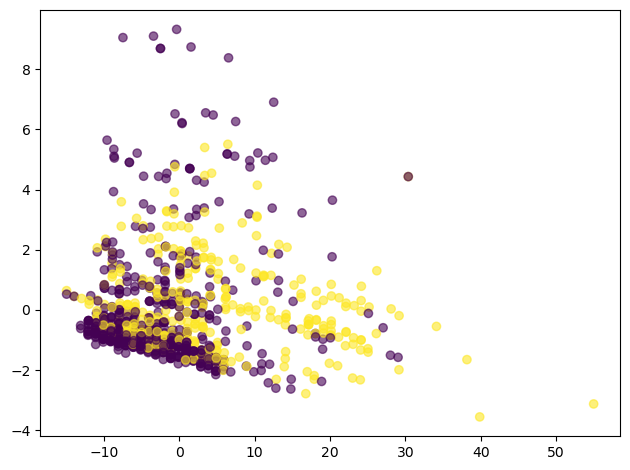

In [9]:
#выделяем целевую переменную и признаки
X = train.drop('Survived', axis=1)  #все кроме Survived
y = train['Survived']  
#разделение train на тренировочную и валидационную выборки
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=17
)
#визуализация выборки
#применяем PCA для уменьшения размерности до 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)


plt.tight_layout()
plt.show()

In [10]:
#Обучtение каждого из объектов из 1-го пункта на получившейся при разбиении тренировочной выборке
lr = LogisticRegression(random_state=17)
lr_grid = GridSearchCV(lr, lr_params, cv=skf, scoring='accuracy')
lr_grid.fit(X_train, y_train)

rfc = RandomForestClassifier(random_state=17)
rfc_grid = GridSearchCV(rfc, rfc_params, cv=skf, scoring='accuracy')
rfc_grid.fit(X_train, y_train)

gbc = GradientBoostingClassifier(random_state=17)
gbc_grid = GridSearchCV(gbc, gbc_params, cv=skf, scoring='accuracy')
gbc_grid.fit(X_train, y_train)

svc = SVC(random_state=17)
svc_grid = GridSearchCV(svc, svc_params, cv=skf, scoring='accuracy')
svc_grid.fit(X_train, y_train)

,estimator,SVC(random_state=17)
,param_grid,"{'C': array([0.1, 0....5, 0.7, 0.9]), 'kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


### 2.
1. Определите объект GridSearchCV для всех приведенных параметров каждого алгоритма (в гиперпараметрах алгоритма при его определении, если возможно, укажите random_state=17). Параметр cv устанавливайте равным skf.

2. Обучите каждый из объектов из 1-го пункта на получившейся при разбиении тренировочной выборке. Выведите лучшее сочетание параметров для каждого из алгоритмов.

3. Для каждого обученного алгоритма получите предсказания на валидационных данных и выведите метрику качества, которая соответствует метрике оценки соревнования.

In [11]:
#вывод лучших параметров
print("GBC best params:", gbc_grid.best_params_)
print("RFC best params:", rfc_grid.best_params_) 
print("SVC best params:", svc_grid.best_params_)
print("LR best params:", lr_grid.best_params_)

GBC best params: {'learning_rate': 0.4}
RFC best params: {'min_samples_leaf': 3, 'n_estimators': 30}
SVC best params: {'C': 0.1, 'kernel': 'linear'}
LR best params: {'C': 0.5}


In [12]:
#создаем модели с лучшими параметрами из GridSearch
lr_best = LogisticRegression(C=0.5, random_state=17)
rfc_best = RandomForestClassifier(min_samples_leaf=2, n_estimators=70, random_state=17)
gbc_best = GradientBoostingClassifier(learning_rate=0.1, random_state=17)
svc_best = SVC(C=0.1, kernel='linear', random_state=17, probability=True)

In [13]:
#обучаем модели
models = [lr_best, rfc_best, gbc_best, svc_best]
for model in models:
    model.fit(X_train, y_train)

### 3.
С помощью GridSearchCV и указанных ниже параметров настройте мета-алгоритм на мета-признаках (используйте 5-кратную валидацию и random_state=17 при определении алгоритма). Матрицу метапризнаков получите из предсказаний, полученных в предыдущем пункте на валидационных данных базовыми алгоритмами. Выведите лучшие параметры.

In [14]:
xgb_params = {'n_estimators': range(10, 100, 5),
              'eta': np.arange(0.1, 1., .1),
              'min_child_weight': range(1, 10, 1),
              'subsample': np.arange(0.1, 1., 0.2)}

In [15]:
from sklearn.metrics import roc_auc_score, accuracy_score

#создаем матрицу мета-признаков для валидационных данных
meta_mtrx = np.empty((X_valid.shape[0], len(models)))  # (кол-во объектов, 4 алгоритма)

for n, model in enumerate(models):
    meta_mtrx[:, n] = model.predict(X_valid)
    predicted = model.predict(X_valid)
    print(f'{n} auc: {roc_auc_score(y_valid, predicted):.4f}')
    print(f'{n} Accuracy: {accuracy_score(y_valid, predicted):.4f}')

0 auc: 0.7884
0 Accuracy: 0.7985
1 auc: 0.7755
1 Accuracy: 0.7910
2 auc: 0.7601
2 Accuracy: 0.7761
3 auc: 0.7807
3 Accuracy: 0.7910


In [16]:
#используем XGBClassifier
meta = XGBClassifier(random_state=17)
meta_grid = GridSearchCV(meta, xgb_params, cv=skf, scoring='accuracy')
meta_grid.fit(meta_mtrx, y_valid)

print("Лучшие параметры мета-алгоритма:", meta_grid.best_params_)
print("Лучший score мета-алгоритма:", meta_grid.best_score_)

Лучшие параметры мета-алгоритма: {'eta': 0.7000000000000001, 'min_child_weight': 7, 'n_estimators': 65, 'subsample': 0.30000000000000004}
Лучший score мета-алгоритма: 0.8171907756813418


### 4.
На основе алгоритма из предыдущего домашнего задания постройте стекинг (используйте 5-кратную кросс-валидацию) для всех моделей с наилучшими подобранными параметрами. В качестве тренировочных данных используйте весь датасет train.csv, а в качестве тестовых - весь датасет test.csv. Сделайте прогноз мета-алгоритма для test.csv.

In [22]:
X_train_full = train.drop('Survived', axis=1)  
y_train_full = train['Survived']               
X_test_full = test         


In [23]:
#cоздаем модели с лучшими параметрами
lr_best = LogisticRegression(C=0.5, random_state=17)
rfc_best = RandomForestClassifier(min_samples_leaf=2, n_estimators=70, random_state=17)
gbc_best = GradientBoostingClassifier(learning_rate=0.1, random_state=17)
svc_best = SVC(C=0.1, kernel='linear', random_state=17, probability=True)

models_best = [lr_best, rfc_best, gbc_best, svc_best]

In [28]:
#мета-алгоритм с ВСЕМИ лучшими параметрами
meta_best = XGBClassifier(
    eta=0.7000000000000001,          #learning_rate
    n_estimators=65,                 #количество деревьев
    min_child_weight=7,              #минимальный вес для разделения
    subsample=0.30000000000000004,   #доля samples для обучения каждого дерева
    random_state=17
)



In [32]:
from sklearn.model_selection import cross_val_predict
def stacking(models, meta_alg, data_train, targets_train, data_test, targets_test=None, random_state=None, test_size=None, cv=5):
    if test_size is None:
        #используем кросс-валидацию для создания мета-признаков
        
        #определяем матрицу meta_mtrx
        meta_mtrx = np.empty((data_train.shape[0], len(models)))
        
        #цикл для заполнения матрицы meta_mtrx
        for n, model in enumerate(models):
            #каждый столбец метапризнаков заполняется с помощью cross_val_predict
            meta_mtrx[:, n] = cross_val_predict(model, data_train, targets_train, cv=cv, method='predict')
            
            #обучаем каждый базовый алгоритм на полном тренировочном датасете
            model.fit(data_train, targets_train)
        
        #обучаем мета-алгоритм на матрице метапризнаков
        meta_alg.fit(meta_mtrx, targets_train)
        
        #определяем матрицу meta_mtrx_test
        meta_mtrx_test = np.empty((data_test.shape[0], len(models)))
        
        #цикл для заполнения матрицы meta_mtrx_test
        for n, model in enumerate(models):
            # Матрица заполняется предсказаниями базовых моделей на тестовых данных
            meta_mtrx_test[:, n] = model.predict(data_test)
        
        #предсказания мета-алгоритма для значений матрицы meta_mtrx_test
        meta_predictions = meta_alg.predict(meta_mtrx_test)
        
        #проверка для targets_test и вывод roc_auc_score
        if targets_test is not None:
            auc_score = roc_auc_score(targets_test, meta_predictions)
            print(f"Stacking AUC: {auc_score:.4f}")
            
        return meta_predictions
    
    elif test_size > 0 and test_size < 1:
        #деление data_train и targets_train на тренировочные и валидационные данные
        X_train, X_valid, y_train, y_valid = train_test_split(
            data_train, targets_train, test_size=test_size, random_state=random_state
        )
        
        #определение матрицы meta_mtrx
        meta_mtrx = np.empty((X_valid.shape[0], len(models)))
        
        #цикл для заполнения meta_mtrx
        for n, model in enumerate(models):
            #модель обучается на тренировочных данных из разбиения
            model.fit(X_train, y_train)
            #матрица заполняется значениями предсказаний моделей на валидационных данных
            meta_mtrx[:, n] = model.predict(X_valid)
        
        #обучение мета-алгоритма на значениях матрицы meta_mtrx
        meta_alg.fit(meta_mtrx, y_valid)
        
        #определение матрицы meta_mtrx_test
        meta_mtrx_test = np.empty((data_test.shape[0], len(models)))
        
        #цикл для заполнения meta_mtrx_test
        for n, model in enumerate(models):
            #матрица заполняется предсказаниями базовых моделей на тестовых данных
            meta_mtrx_test[:, n] = model.predict(data_test)
        
        #предсказания мета-алгоритма для значений матрицы meta_mtrx_test
        meta_predictions = meta_alg.predict(meta_mtrx_test)
        
        #проверка существования targets_test
        if targets_test is not None:
            #вывод метрики roc_auc_score для предсказаний мета-алгоритма
            auc_score = roc_auc_score(targets_test, meta_predictions)
            print(f"Stacking AUC: {auc_score:.4f}")
            
        return meta_predictions
    
    else:
        raise ValueError("test_size must be between 0 and 1")

In [33]:
#запуск скеттинга, используем модель со ВСЕМИ параметрами
predictions3 = stacking(
    models=models_best, 
    meta_alg=meta_best, 
    data_train=X_train_full,
    targets_train=y_train_full,  
    data_test=X_test_full,
    targets_test=None,
    test_size=None,
    cv=5
)

### 5.
С помощью нижеприведенной функции сформируйте файл посылки для соревнования и отправьте на Kaggle.

In [38]:
#мы удалили PassengerId из X_test_full, создадим его заново
PassengerID = range(892, 892 + len(predictions3)) 

In [40]:
def write_to_submission_file(predictions, PassengerID, out_file='Submission.csv', columns=['PassengerID', 'Survived']):
    predicted_df = pd.DataFrame(np.array([PassengerID, predictions]).T, columns=columns)
    predicted_df.to_csv(out_file, index=False)
    print(f"Файл {out_file} успешно создан!")
    return predicted_df

In [41]:
#использование функции
submission_df = write_to_submission_file(predictions3, PassengerID, 'StackingSubmission.csv')

Файл StackingSubmission.csv успешно создан!


In [43]:
submission_df.head(20)

,PassengerID,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [44]:
submission_df.count()

PassengerID    418
Survived       418
dtype: int64

### 6.
Каков результат score, полученного на соревновании?

Ваш ответ:Score: 0.77033